In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

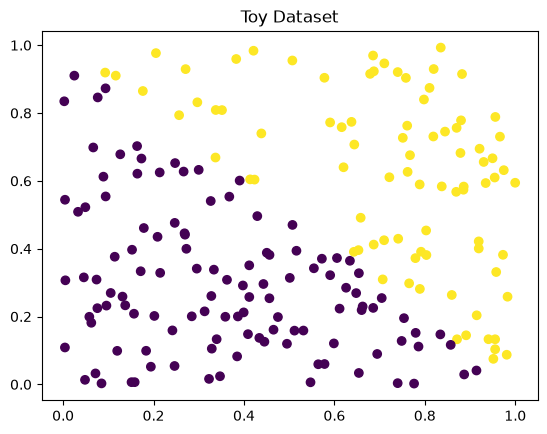

In [2]:
#Simple binary classification is x1 + x2 > 1?
x = torch.rand(200, 2)
y = (x[:,0] + x[:,1] > 1).float().unsqueeze(1)

plt.scatter(x = x[:, 0], y = x[:,1], c=y.squeeze())
plt.title('Toy Dataset')
plt.show()

In [3]:
weight = torch.randn(2, 1, requires_grad = True)
bias = torch.randn(1, requires_grad = True)

def neuron(x):
    z = x @ weight + bias
    return torch.sigmoid(z)
print(f'Initial weight: {weight.detach().flatten()}, bias: {bias.detach()}')

Initial weight: tensor([ 0.6416, -0.5964]), bias: tensor([0.7355])


In [4]:
def BCE_loss(pred, target):
    eps = 1e-7
    pred = torch.clamp(pred, eps, 1-eps)
    return -(target*torch.log(pred) + (1- target) * torch.log(1-pred)).mean()

pred = neuron(x)
loss = BCE_loss(pred, y)

print(f'Initial loss: {loss.item()}')

Initial loss: 0.8332914710044861


Epoch 0, Loss: 0.8333
Epoch 20, Loss: 0.5929
Epoch 40, Loss: 0.5017
Epoch 60, Loss: 0.4411
Epoch 80, Loss: 0.3984
Epoch 100, Loss: 0.3668
Epoch 120, Loss: 0.3424
Epoch 140, Loss: 0.3230
Epoch 160, Loss: 0.3071
Epoch 180, Loss: 0.2938
Epoch 200, Loss: 0.2826
Epoch 220, Loss: 0.2728
Epoch 240, Loss: 0.2643
Epoch 260, Loss: 0.2567
Epoch 280, Loss: 0.2500
Epoch 300, Loss: 0.2439
Epoch 320, Loss: 0.2384
Epoch 340, Loss: 0.2334
Epoch 360, Loss: 0.2288
Epoch 380, Loss: 0.2246
Epoch 400, Loss: 0.2207
Epoch 420, Loss: 0.2171
Epoch 440, Loss: 0.2137
Epoch 460, Loss: 0.2105
Epoch 480, Loss: 0.2075
Epoch 500, Loss: 0.2047
Epoch 520, Loss: 0.2021
Epoch 540, Loss: 0.1996
Epoch 560, Loss: 0.1972
Epoch 580, Loss: 0.1950
Epoch 600, Loss: 0.1928
Epoch 620, Loss: 0.1908
Epoch 640, Loss: 0.1888
Epoch 660, Loss: 0.1870
Epoch 680, Loss: 0.1852
Epoch 700, Loss: 0.1835
Epoch 720, Loss: 0.1818
Epoch 740, Loss: 0.1802
Epoch 760, Loss: 0.1787
Epoch 780, Loss: 0.1772
Epoch 800, Loss: 0.1758
Epoch 820, Loss: 0.174

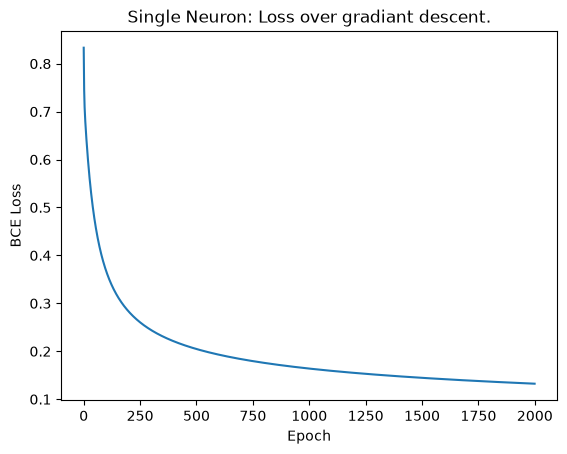

In [5]:
lr = 0.8
losses = []

for epoch in range(2000):
    pred = neuron(x)
    loss = BCE_loss(pred, y)

    loss.backward() #backward propagation

    with torch.no_grad():
        weight -= lr * weight.grad
        bias -= lr * bias.grad

    # zero gradiant for next iteration
    weight.grad.zero_()
    bias.grad.zero_()

    losses.append(loss.item())

    if epoch % 20 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

plt.plot(losses)
plt.title('Single Neuron: Loss over gradiant descent.')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.show()

In [6]:
class FeedforwardNet(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.layer_2 = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        return self.sigmoid(x)

model = FeedforwardNet(input_dim = 2, hidden_dim=8, output_dim=1)
print(model)

FeedforwardNet(
  (layer_1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (layer_2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
losses_nn = []

for epoch in range(251):
    #Forward pass
    pred = model(x)
    loss = BCE_loss(pred, y)

    #Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 50 == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item():.4f}')
        

Epoch: 0, Loss: 0.6997
Epoch: 50, Loss: 0.6624
Epoch: 100, Loss: 0.6128
Epoch: 150, Loss: 0.5339
Epoch: 200, Loss: 0.4385
Epoch: 250, Loss: 0.3541


Accuracy: 94.50%


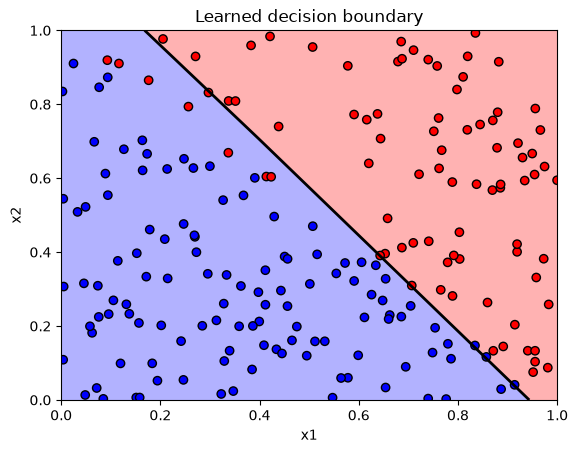

In [12]:
with torch.no_grad():
    preds = model(x) > 0.5
    accuracy = (preds.float() == y).float().mean()
    print(f'Accuracy: {accuracy.item() * 100:.2f}%')

xx, yy = torch.meshgrid(torch.linspace(0, 1, 100), torch.linspace(0, 1, 100), indexing='ij')
grid = torch.stack([xx.flatten(), yy.flatten()], dim=1)


with torch.no_grad():
    grid_preds = model(grid).reshape(100, 100).cpu()

#Filled region (just two colors red and blue)
plt.contourf(xx, yy, grid_preds, levels= [0, 0.5, 1], colors=['blue', 'red'], alpha=0.3)

#single crisp decision boundary line at probability 0.5
plt.contour(xx, yy, grid_preds, levels=[0.5], colors=['black'], linewidths = 2)

#Data points
plt.scatter(x[:,0], x[:,1], c=y.squeeze(), cmap='bwr', edgecolors='k')

plt.title('Learned decision boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()